In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

In [2]:
root = "/home/mustavi/CompV/datasets/cub2002011/versions/7/CUB_200_2011"  
images_txt = os.path.join(root, "images.txt")
bbox_txt = os.path.join(root, "bounding_boxes.txt")
part_locs_txt = os.path.join(root, "parts", "part_locs.txt")
images_folder = os.path.join(root, "images")

In [3]:
images_df = pd.read_csv(images_txt, sep=" ", header=None, names=["img_id", "img_path"])

bbox_df = pd.read_csv(bbox_txt, sep=" ", header=None, names=["img_id", "x", "y", "w", "h"])
bbox_df["x2"] = bbox_df["x"] + bbox_df["w"]
bbox_df["y2"] = bbox_df["y"] + bbox_df["h"]

parts_df = pd.read_csv(part_locs_txt, sep=" ", header=None, names=["img_id", "part_id", "x", "y", "visible"])



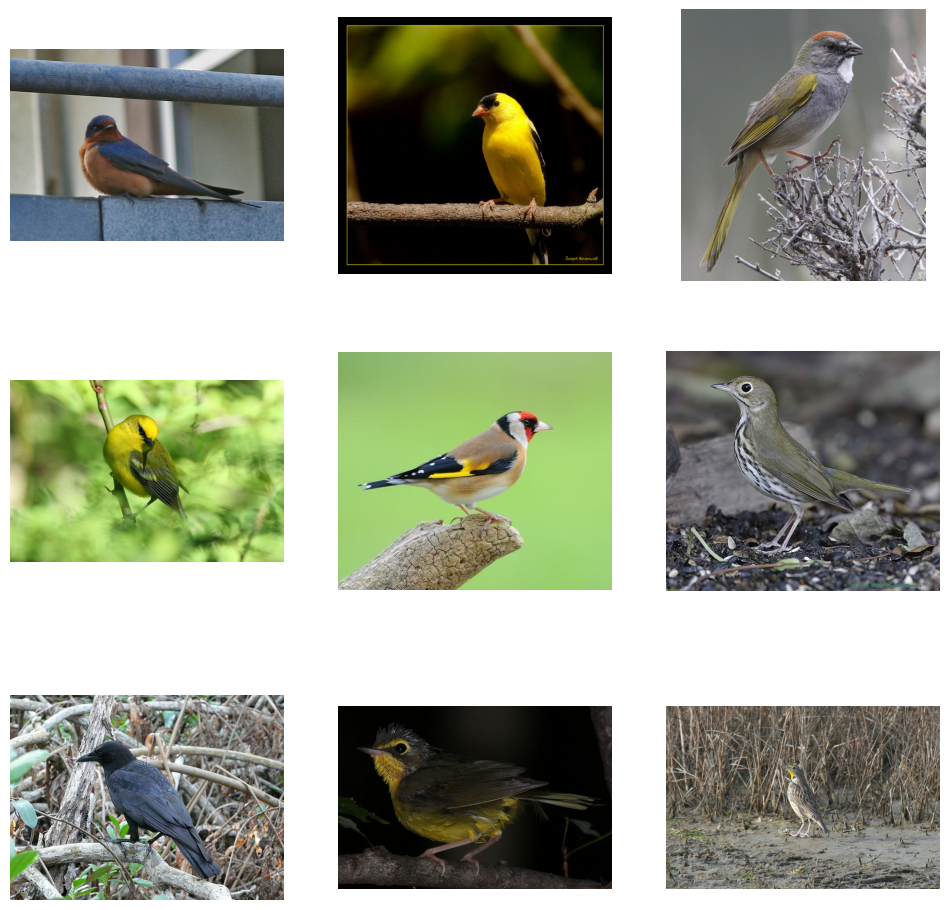

In [4]:
def show_random_images(n=9):
    sample = images_df.sample(n)
    fig, axes = plt.subplots(3, 3, figsize=(12,12))
    for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
        img_path = os.path.join(images_folder, row["img_path"])
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis('off')
    plt.show()

show_random_images(9)

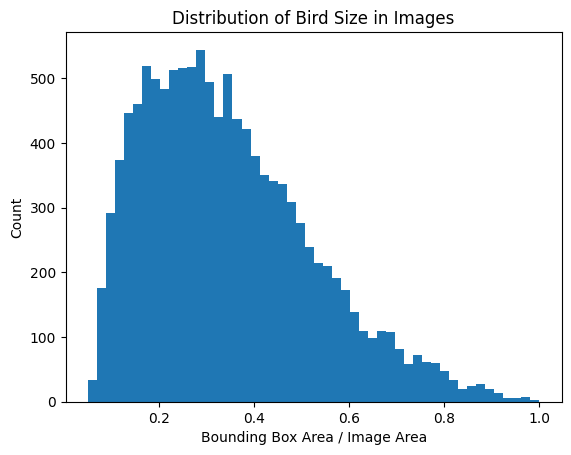

In [5]:
ratios = []
for _, row in images_df.iterrows():
    img_id = row["img_id"]
    img_path = os.path.join(images_folder, row["img_path"])
    img = Image.open(img_path)
    img_area = img.size[0] * img.size[1]
    bb = bbox_df[bbox_df["img_id"] == img_id].iloc[0]
    box_area = bb["w"] * bb["h"]
    ratios.append(box_area / img_area)

plt.hist(ratios, bins=50)
plt.xlabel("Bounding Box Area / Image Area")
plt.ylabel("Count")
plt.title("Distribution of Bird Size in Images")
plt.show()

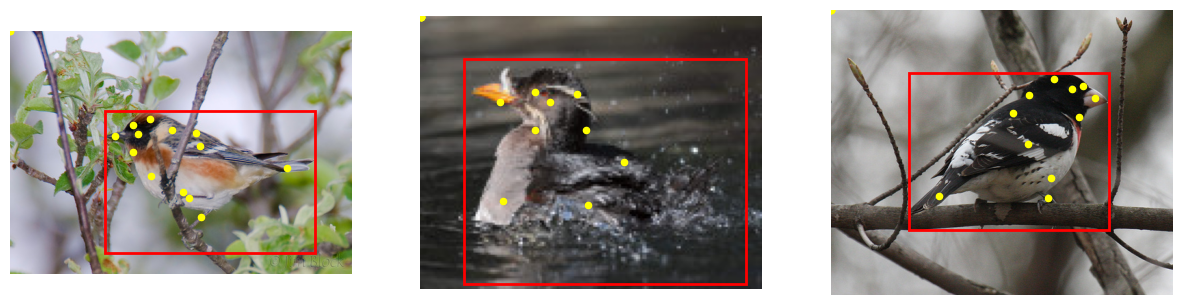

In [11]:

def show_keypoints(img_id, ax):
    # get bounding box
    bb = bbox_df[bbox_df["img_id"] == img_id].iloc[0]
    # load image
    img_path = images_df[images_df["img_id"] == img_id]["img_path"].values[0]
    img = Image.open(os.path.join(images_folder, img_path))
    ax.imshow(img)
    # plot bbox
    ax.add_patch(plt.Rectangle((bb["x"], bb["y"]), bb["w"], bb["h"], 
                edgecolor="red", facecolor="none", lw=2))
    # plot parts
    parts = parts_df[parts_df["img_id"] == img_id]
    ax.scatter(parts["x"], parts["y"], marker='o', c='yellow', s=20)
    ax.axis('off')

# Show a few with keypoints
fig, axes = plt.subplots(1, 3, figsize=(15,5))
sample_ids = images_df["img_id"].sample(10).values
for ax, img_id in zip(axes, sample_ids):
    show_keypoints(img_id, ax)
plt.show()